Tutorial uses CIFAR-10 data, we'll use MNIST data instead: https://www.tensorflow.org/tutorials/images/cnn

NOTES:
- *VGG influence*: stack of 3x3 Conv2D followed by 3x3 MaxPool, with increase in filters (channels) to account for reduced spatial dimensions (due to no padding), then finally flatten and dense.
- `SparseCategoricalCrossentropy()` used here because our expected labels are encoded numerically (0,1,2..) ; if instead they were one-hot encoded (eg. if class 0 is out then [1,0,0]) then `CategoricalCrossentropy` would be used instead.

MISC NOTES:
- Loss functions (these are most common ones, others also exist in these & other classes):
    - Binary Classification: `BinaryCrossentropy`
    - Multi-class Classification: `SparseCategoricalCrossentropy` (when out classes are numerical: 0,1,2..) | `CategoricalCrossentropy` (classes are one-hot encoded)
    - Regression: `MeanSquaredError` (normally distrib errors, eg. bounding box coords) | `MeanAbsoluteError` (deal with outliers but less smooth optimization)
    - Object Detection: Combination of IoU Loss, BinaryCrossentropy (for classification), and SmoothL1Loss (for regression of coordinates)
    - Segmentation: Crossentropy (most common) | Dice Loss (for imbalanced data)

- Standardize / Z Score $\frac{X - avg(X)}{std(X)}$ vs Min-Max Normalize $\frac{X - X_{min}}{X_{max} - X_{min}}$

## Test & Train

In [1]:
import numpy as np
import pandas as pd
from sklearn import preprocessing           # "import sklearn" and then sklearn.preprocessing DOES NOT works
import tensorflow as tf
import matplotlib.pyplot as plt

2024-12-25 14:51:36.367858: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
train_images, test_images = train_images / 255, test_images / 255       # normalize: 0-255 --> 0-1
# MNIST has grayscale images with 2 axes, but Conv2D requires 3 axes, so add (,1) channels dimension at end: (batch_size,x,y) --> (batch_size,x,y,1)
train_images, test_images = np.expand_dims(train_images, axis=-1), np.expand_dims(test_images, axis=-1)   
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 28, 28, 1), (60000,), (10000, 28, 28, 1), (10000,))

In [3]:
def describe(arr):
    return {'min': np.min(arr), 'max': np.max(arr)}

[describe(x) for x in (train_images, train_labels, test_images, test_labels)]

[{'min': np.float64(0.0), 'max': np.float64(1.0)},
 {'min': np.uint8(0), 'max': np.uint8(9)},
 {'min': np.float64(0.0), 'max': np.float64(1.0)},
 {'min': np.uint8(0), 'max': np.uint8(9)}]

In [4]:
out = x = tf.keras.Input((28,28,1), name='input')         # same as image shape above of MNIST data; (,1) channels=1 since MNIST has grayscale images
out = tf.keras.layers.Conv2D(32, (3,3), activation='relu', name='conv2d_1')(out)
out = tf.keras.layers.MaxPool2D((2,2), name='maxpool_1')(out)
out = tf.keras.layers.Conv2D(64, (3,3), activation='relu', name='conv2d_2')(out)
out = tf.keras.layers.MaxPool2D((2,2), name='maxpool_2')(out)
out = tf.keras.layers.Conv2D(64, (3,3), activation='relu', name='conv2d_3')(out)
out = tf.keras.layers.MaxPool2D((2,2), name='maxpool_3')(out)
out = tf.keras.layers.Flatten(name='flatten')(out)
out = tf.keras.layers.Dense(64, activation='relu', name='dense')(out)
# 10 is no. of output classes (since 10 digits) in MNIST data - look at range of labels (0-9 means total 10) in previous "describe" cell
out = tf.keras.layers.Dense(10, activation='softmax', name='out')(out)
model = tf.keras.Model(inputs=x, outputs=out)
model.compile(
    optimizer='adam', 
    # tutorial had from_logits=True because they didn't use softmax in out layer, so raw logits had to be converted here to probabilities
    # but I already used softmax in output layer so from_logits not required
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),    
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_3 (MaxPooling2D)        │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,554 (236.54 KB)

 Trainable params: 60,554 (236.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(train_images, train_labels, epochs=3, validation_data=(test_images, test_labels))   

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.8521 - loss: 0.4604 - val_accuracy: 0.9792 - val_loss: 0.0681
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9789 - loss: 0.0706 - val_accuracy: 0.9838 - val_loss: 0.0528
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9841 - loss: 0.0499 - val_accuracy: 0.9813 - val_loss: 0.0601


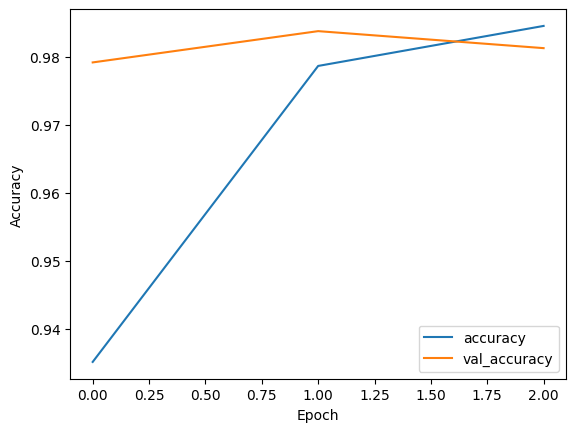

In [6]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
#plt.ylim([0.9,1])      # put these lims because observed in graph accuracies between these only
plt.legend(loc='lower right')
plt.show()

In [ ]:
# NOTE: must call them immediately first thing after training without calling anything else first, otherwise it behaves wierdly
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=2)
print(f'{test_loss=}, {test_accuracy=}')

313/313 - 2s - 6ms/step - accuracy: 0.9813 - loss: 0.0601
test_loss=0.060051240026950836, test_accuracy=0.9812999963760376


6


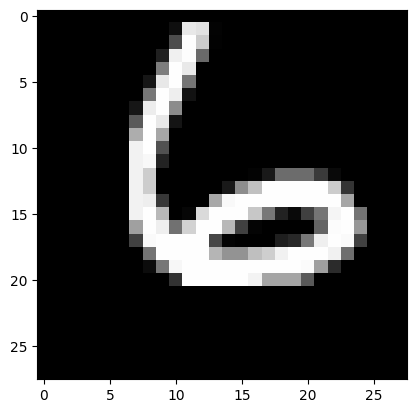

In [8]:
# random test image
batch_size = test_images.shape[0]
test_img_index = np.random.randint(0, batch_size)
img = test_images[test_img_index]       # random test image
print(test_labels[test_img_index])
plt.imshow(img, cmap='grey')

### Different Model Calling methods

In [ ]:
# model() vs model.predict() : https://stackoverflow.com/a/70205891/12947681
# in tensorflow you always give a batch of images to predict
batch = np.expand_dims(img, axis=0)          # batch of single image
preds: list[list[int]] = model.predict(batch)          # most commonly used (high-level); scalable
print(preds)
print('Out indices:', [np.argmax(img_preds) for img_preds in preds])      # since this is MNIST digits data, index is same as label - for others map index to label

pred_tensor: tf.Tensor = model(batch)      
print(pred_tensor)                  # use while impl lower-level gradient descent training loop: returns tensor from which gradient can be retrieved
# model.call(batch) - this also returns tensor like model(batch); IDK what's difference

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[1.0798132e-06 2.6891645e-11 9.8760402e-06 1.0758761e-10 4.8433969e-05
  4.9840428e-06 9.9992871e-01 7.5814410e-10 6.9359303e-06 9.3267194e-10]]
Out indices: [np.int64(6)]
tf.Tensor(
[[1.0798132e-06 2.6891645e-11 9.8760402e-06 1.0758761e-10 4.8433969e-05
  4.9840428e-06 9.9992871e-01 7.5814410e-10 6.9359303e-06 9.3267194e-10]], shape=(1, 10), dtype=float32)


## Visualizing CNN Layers
https://machinelearningmastery.com/how-to-visualize-filters-and-feature-maps-in-convolutional-neural-networks/

2 options:
- [x] Visualize kernel weights (here meaningful since Convolution kernel has spatially related weights)
- [x] (more useful) Visualize feature map. 
- [ ] feature map *TODO: in Deep Learning a Visual Approach, they are optimizing input image for feature map (like gradient descent, but in reverse, optimizing image and freezing weights). Try that*

**I don't yet actually have an intuition or understanding of what precisely visualizations imply, what each image tells me about what it's learnt & how to improve it**

In [24]:
def funcmodel_summary(model: tf.keras.Model) -> pd.DataFrame:
    return pd.DataFrame([
        {
            'name': layer.name,
            'input_shape': [x.shape for x in layer.input] if isinstance(layer.input, list) else layer.input.shape,   
            'output_shape': layer.output.shape,
            **{f'w_{weights_info.name}_shape': weights_info.shape for weights_info in layer.weights}
        }
        for layer in model.layers[1:]       # skip input layer
    ])

funcmodel_summary(model)


,name,input_shape,output_shape,w_kernel_shape,w_bias_shape
0,conv2d_1,"(None, 28, 28, 1)","(None, 26, 26, 32)","(3, 3, 1, 32)",(32)
1,maxpool_1,"(None, 26, 26, 32)","(None, 13, 13, 32)",NaN,NaN
2,conv2d_2,"(None, 13, 13, 32)","(None, 11, 11, 64)","(3, 3, 32, 64)",(64)
3,maxpool_2,"(None, 11, 11, 64)","(None, 5, 5, 64)",NaN,NaN
4,conv2d_3,"(None, 5, 5, 64)","(None, 3, 3, 64)","(3, 3, 64, 64)",(64)
5,maxpool_3,"(None, 3, 3, 64)","(None, 1, 1, 64)",NaN,NaN
6,flatten,"(None, 1, 1, 64)","(None, 64)",NaN,NaN
7,dense,"(None, 64)","(None, 64)","(64, 64)",(64)
8,out,"(None, 64)","(None, 10)","(64, 10)",(10)


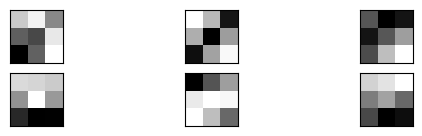

In [13]:
# Visualize weights matrix; it shows dark (weight high) and white (weight low) but I don't understand what that tells us

weights, biases = model.get_layer('conv2d_1').get_weights()        # first hidden conv layer
weights = (weights - weights.min()) / (weights.max() - weights.min())     # normalize b/w 0 and 1
n_filters = 6       # to plot
for i in range(n_filters):
    # NOTE: since MNIST grayscale images were used, so first conv layer has only 1 input channel
    # weight matrix axes: (kernel_height, kernel_width, input_channels, output_channels)
    filter_w = weights[:, :, 0, i]    # since out channels at last pos in default channels-last
    # org code looped here over 3 RGB channels, but not req here since only 1 input channel
    ax = plt.subplot(n_filters, 3, i+1)      # i+1 since matplotlib wants 1-based index; 3 here refers to kernel size (3,3) of Conv2D
    ax.set_xticks([])
    ax.set_yticks([])
    plt.imshow(filter_w, cmap='gray')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
(1, 26, 26, 32)


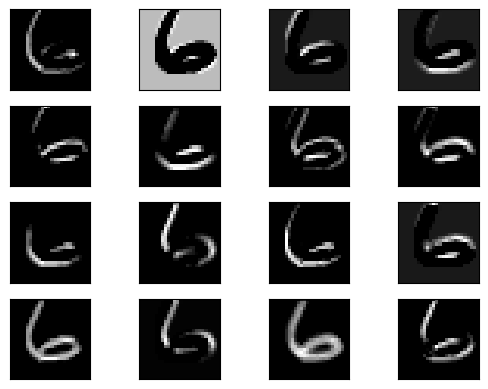

In [23]:
# Visualize feature maps for first conv2d layer
new_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer('conv2d_1').output)          # get output of only this conv2d layer
preds = new_model.predict(batch)
print(preds.shape)
# plot 16 out of 32 (because 32 isn't a perfect square, 16 is 😀 ) filters' feature maps (conv2d_1 has 32 output filters/channels)
square = 4
ix = 1
for _ in range(square):
	for _ in range(square):
		ax = plt.subplot(square, square, ix)
		ax.set_xticks([])
		ax.set_yticks([])
		plt.imshow(preds[0, :, :, ix-1], cmap='gray')      # first index 0 because batch has only one image
		ix += 1
plt.show()